# 企業間エントロピー比較

指定した複数企業について、同一年の **年間出願件数** と **区分別エントロピー** を比較する。

| 軸 | 意味 |
|---|---|
| x（年間出願件数） | その年に出願した延べ区分数の合計 |
| y（正規化エントロピー） | 0 = 特定区分に集中、1 = 全45区分に均等分散 |

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from utils.db import get_conn
from utils.trademark_utils import parse_filing_date, extract_classes, calc_entropy

matplotlib.rcParams['font.family'] = 'Meiryo'
print('セットアップ完了')

セットアップ完了


---

## 1. 検索条件の入力

`target_year` と `target_company_ids` を設定してから次のセルを実行すること。

In [8]:
# ===== 検索条件を入力 =====
target_year        = 2020   # 例: 2020
target_company_ids = [131094, 135748, 134855, 3584, 307010096, 506113602, 105637, 595030295, 500040182, 106195, 505187024, 505269995, 709006024]   # 例: [131094, 3207, 186588]
# ==========================

# --- 入力値の検証 ---
_errors = []
if target_year is None:
    _errors.append('  • target_year が未設定です（西暦4桁の整数）')
if not target_company_ids:
    _errors.append('  • target_company_ids が未設定です（整数のリスト）')
if _errors:
    raise ValueError(
        '以下の入力が不足しています。値を設定してからセルを再実行してください。\n'
        + '\n'.join(_errors)
    )

print(f'対象年      : {target_year}')
print(f'対象企業 ID : {target_company_ids}  （{len(target_company_ids)} 社）')

対象年      : 2020
対象企業 ID : [131094, 135748, 134855, 3584, 307010096, 506113602, 105637, 595030295, 500040182, 106195, 505187024, 505269995, 709006024]  （13 社）


---

## 2. データ取得

In [9]:
with get_conn() as conn:
    df_fetched = pd.read_sql("""
        SELECT
            "right-holder-group-identification-number"  AS company_id,
            "right-holder-group-name"                   AS company_name,
            "filing-date"                               AS filing_date_raw,
            "goods-and-service-name-and-code"           AS goods_and_service,
            "number-of-goods-service-class"             AS num_classes
        FROM trademark_db
        WHERE "goods-and-service-name-and-code"             IS NOT NULL
          AND "filing-date"                                  IS NOT NULL
          AND "right-holder-group-identification-number"    = ANY(%(ids)s)
    """, conn, params={'ids': target_company_ids})

if df_fetched.empty:
    raise ValueError(
        f'指定した company_ids {target_company_ids} に該当するデータが見つかりませんでした。'
    )

# 出願日をパースして target_year でフィルタ
df_fetched['filing_date'] = df_fetched['filing_date_raw'].apply(parse_filing_date)
df_fetched['filing_year'] = df_fetched['filing_date'].apply(lambda d: d.year if d else None)
df_year = df_fetched[df_fetched['filing_year'] == target_year].copy()

# 取得できなかった企業を報告
found_ids    = set(df_year['company_id'].unique())
missing_ids  = set(target_company_ids) - found_ids
if missing_ids:
    print(f'[警告] {target_year}年のデータが見つからなかった company_id: {sorted(missing_ids)}')

if df_year.empty:
    raise ValueError(
        f'{target_year}年のデータがいずれの企業にも見つかりませんでした。'
    )

print(f'取得件数: {len(df_year):,} 件  対象企業数: {len(found_ids)} 社')
df_year.head(3)

C:\Users\k-fukuzawa\AppData\Local\Temp\ipykernel_43604\1875605410.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fetched = pd.read_sql("""


[警告] 2020年のデータが見つからなかった company_id: [105637]
取得件数: 1,044 件  対象企業数: 12 社


,company_id,company_name,filing_date_raw,goods_and_service,num_classes,filing_date,filing_year
1,3584,株式会社タカラトミー,令和２年６月２５日（２０２０．６．２５）,第２８類 遊園地用機械器具，業務用テレビゲーム機，おもちゃ，人形，囲碁用具，将棋用具，歌が...,1,2020-06-25,2020
2,3584,株式会社タカラトミー,令和２年６月２５日（２０２０．６．２５）,第２８類 遊園地用機械器具，業務用テレビゲーム機，おもちゃ，人形，囲碁用具，将棋用具，歌が...,1,2020-06-25,2020
3,135748,株式会社バンダイ,令和２年４月１日（２０２０．４．１）,第２８類 遊園地用機械器具，業務用テレビゲーム機，ペット用おもちゃ，トレーディングカードゲ...,1,2020-04-01,2020


---

## 3. 前処理（区分番号の展開）

In [10]:
df_year['class_list'] = df_year['goods_and_service'].apply(extract_classes)

df_exploded = (
    df_year
    .explode('class_list')
    .dropna(subset=['class_list'])
    .rename(columns={'class_list': 'class_number'})
    .astype({'class_number': int})
)

print(f'展開後件数: {len(df_exploded):,} 件')

展開後件数: 2,800 件


---

## 4. エントロピー計算

In [11]:
# 企業ごとの年間平均区分数（出願単位の num_classes を平均）
avg_classes_map = df_year.groupby('company_id')['num_classes'].mean().to_dict()

rows = []
for (cid, cname), grp in df_exploded.groupby(['company_id', 'company_name']):
    counts = grp.groupby('class_number')['class_number'].count()
    metrics = calc_entropy(counts)
    rows.append({
        'company_id':          cid,
        'company_name':        cname,
        'avg_classes':         avg_classes_map.get(cid),
        **metrics,
    })

df_result = (
    pd.DataFrame(rows)
    .sort_values('entropy_normalized', ascending=False)
    .reset_index(drop=True)
)[['company_id', 'company_name', 'total_applications', 'avg_classes', 'entropy', 'entropy_normalized', 'n_classes_used']]

df_result.columns = [
    '企業ID', '企業名',
    '年間出願件数（延べ区分）',
    '1出願あたり平均区分指定数',
    'エントロピー (bits)', '正規化エントロピー',
    '使用区分数',
]
df_result['1出願あたり平均区分指定数'] = df_result['1出願あたり平均区分指定数'].round(2)

print(f'{target_year}年  企業間エントロピー比較')
df_result

2020年  企業間エントロピー比較


,企業ID,企業名,年間出願件数（延べ区分）,1出願あたり平均区分指定数,エントロピー (bits),正規化エントロピー,使用区分数
0,131094,株式会社サンリオ,1445,2.66,5.3037,0.9657,44
1,500040182,東映アニメーション株式会社,58,9.67,4.4316,0.8069,23
2,135748,株式会社バンダイ,322,2.58,3.7205,0.6774,30
3,134855,株式会社バンダイナムコエンターテインメント,295,4.34,3.6048,0.6564,18
4,595030295,株式会社タカラトミーアーツ,46,5.11,3.5933,0.6543,16
5,505187024,株式会社スタジオジブリ,12,12.00,3.5850,0.6528,12
6,106195,サンエックス株式会社,44,3.67,3.3691,0.6135,12
7,709006024,株式会社ベネッセコーポレーション,77,3.67,3.1068,0.5657,14
8,307010096,フリュー株式会社,145,2.64,2.9934,0.5451,14
9,505269995,エイベックス株式会社,42,2.47,2.7660,0.5037,10


---

## 5. 散布図：年間出願件数 × 正規化エントロピー

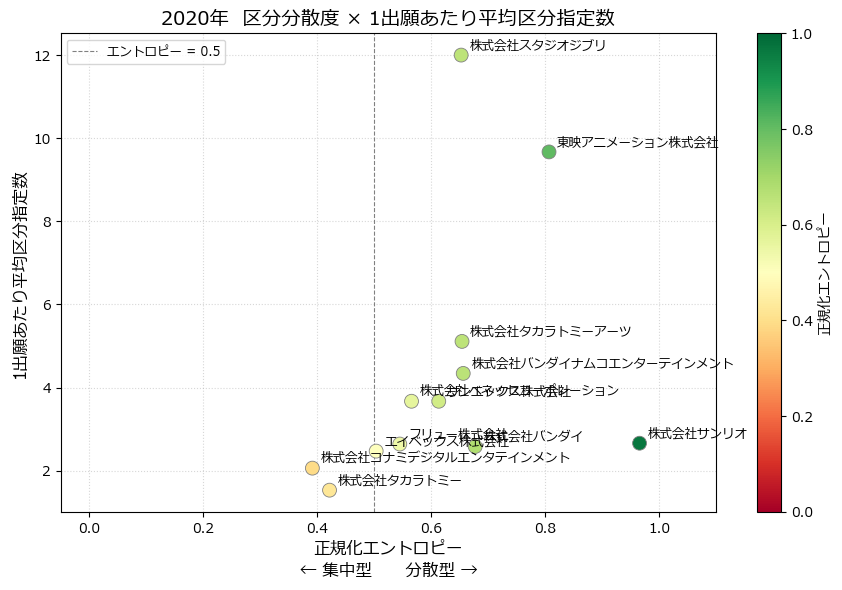

In [12]:
x = df_result['正規化エントロピー']
y = df_result['1出願あたり平均区分指定数']
names = df_result['企業名']

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    x, y,
    c=x, cmap='RdYlGn', vmin=0, vmax=1,
    s=100, edgecolors='grey', linewidths=0.6, zorder=3
)

# 企業名ラベルを各点の右上に表示
for xi, yi, name in zip(x, y, names):
    ax.annotate(
        name,
        xy=(xi, yi), xytext=(6, 4),
        textcoords='offset points',
        fontsize=9,
    )

# 参考線（エントロピー 0.5 の垂直線）
ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8, label='エントロピー = 0.5')

fig.colorbar(scatter, ax=ax, label='正規化エントロピー')

ax.set_xlabel('正規化エントロピー\n← 集中型　　分散型 →', fontsize=12)
ax.set_ylabel('1出願あたり平均区分指定数', fontsize=12)
ax.set_title(f'{target_year}年  区分分散度 × 1出願あたり平均区分指定数', fontsize=14)
ax.set_xlim(-0.05, 1.1)
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()